# This notebook implements five algorithmic paradigm tasks:
This notebook implements five algorithmic paradigm tasks:
1. Divide and Conquer Algorithms
2. Sorting Performance Comparison
3. Greedy Algorithms
4. Dynamic Programming Fundamentals
5. Travelling Salesman Problem (TSP)

In [2]:
# ── Global Imports ──────────────────────────────────────────────────────────
import time
import random
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from memory_profiler import memory_usage

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('All imports successful ✓')

All imports successful ✓


# Task 1 — Divide and Conquer Algorithms
**Strategy:** Split the problem into smaller sub-problems, solve recursively, and combine results.  
**Algorithms implemented:**
- **Merge Sort** — O(n log n) sorting via splitting and merging
- **Binary Search** — O(log n) search on sorted arrays
- **Power (Fast Exponentiation)** — O(log n) via repeated squaring



In [4]:
# ── 1.1  Merge Sort ─────────────────────────────────────────────────────────

def merge_sort(arr):
    """Recursively split and merge — O(n log n)."""
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left  = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return _merge(left, right)

def _merge(left, right):
    result, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result


# ── 1.2  Binary Search ──────────────────────────────────────────────────────

def binary_search(arr, target):
    """Search sorted array — O(log n). Returns index or -1."""
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1


# ── 1.3  Fast Exponentiation ─────────────────────────────────────────────────

def fast_power(base, exp):
    """Compute base^exp via repeated squaring — O(log n)."""
    if exp == 0:
        return 1
    if exp % 2 == 0:
        half = fast_power(base, exp // 2)
        return half * half
    return base * fast_power(base, exp - 1)


# ── Correctness Checks ───────────────────────────────────────────────────────
sample = [38, 27, 43, 3, 9, 82, 10]
sorted_sample = merge_sort(sample)
print(f"Merge Sort:    {sample} → {sorted_sample}")

idx = binary_search(sorted_sample, 27)
print(f"Binary Search: target=27 found at index {idx} → value={sorted_sample[idx]}")

print(f"Fast Power:    2^10 = {fast_power(2, 10)}  (expected 1024)")

Merge Sort:    [38, 27, 43, 3, 9, 82, 10] → [3, 9, 10, 27, 38, 43, 82]
Binary Search: target=27 found at index 3 → value=27
Fast Power:    2^10 = 1024  (expected 1024)


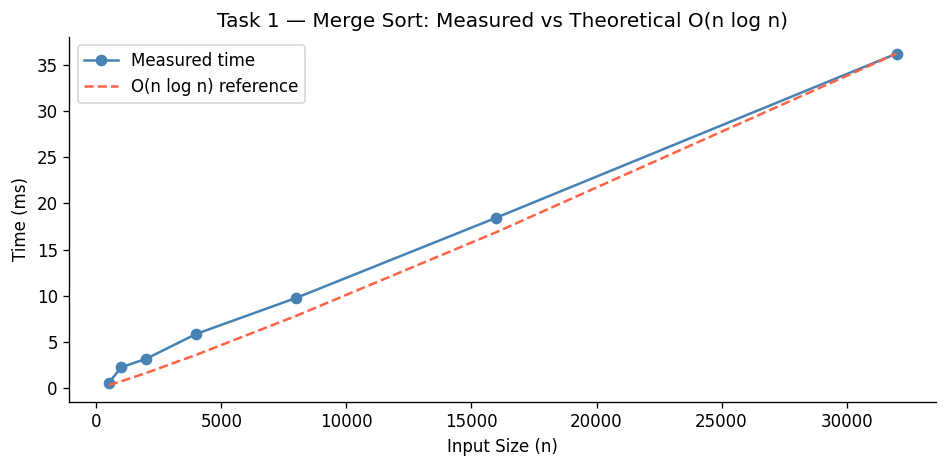

In [5]:
# ── 1.4  Performance Profiling — Merge Sort vs Input Size ───────────────────

sizes_dc = [500, 1000, 2000, 4000, 8000, 16000, 32000]
times_ms = []

for n in sizes_dc:
    data = random.sample(range(n * 10), n)
    t0 = time.perf_counter()
    merge_sort(data)
    times_ms.append((time.perf_counter() - t0) * 1000)

# Theoretical n log n curve scaled to match
theory = [n * math.log2(n) for n in sizes_dc]
scale  = times_ms[-1] / theory[-1]
theory_scaled = [v * scale for v in theory]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sizes_dc, times_ms, 'o-', color='steelblue', label='Measured time')
ax.plot(sizes_dc, theory_scaled, '--', color='tomato', label='O(n log n) reference')
ax.set_xlabel('Input Size (n)')
ax.set_ylabel('Time (ms)')
ax.set_title('Task 1 — Merge Sort: Measured vs Theoretical O(n log n)')
ax.legend()
plt.tight_layout()

plt.show()


## Task 2 — Sorting Performance Comparison

**Algorithms compared:**
- Bubble Sort — O(n²)
- Insertion Sort — O(n²) best O(n)
- Merge Sort — O(n log n)
- Quick Sort — O(n log n) avg
- Python built-in `sorted()` (Timsort) — O(n log n)

In [6]:
# ── 2.1  Algorithm Implementations ──────────────────────────────────────────

def bubble_sort(arr):
    """O(n²) — compares adjacent pairs repeatedly."""
    a = arr[:]
    n = len(a)
    for i in range(n):
        for j in range(0, n - i - 1):
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
    return a

def insertion_sort(arr):
    """O(n²) avg, O(n) best — builds sorted array one item at a time."""
    a = arr[:]
    for i in range(1, len(a)):
        key, j = a[i], i - 1
        while j >= 0 and a[j] > key:
            a[j + 1] = a[j]
            j -= 1
        a[j + 1] = key
    return a

def quick_sort(arr):
    """O(n log n) avg, O(n²) worst — partition around pivot."""
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr) // 2]
    left  = [x for x in arr if x < pivot]
    mid   = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + mid + quick_sort(right)

def timsort_wrapper(arr):
    return sorted(arr)

# merge_sort already defined in Task 1

algorithms = {
    'Bubble Sort':    bubble_sort,
    'Insertion Sort': insertion_sort,
    'Merge Sort':     merge_sort,
    'Quick Sort':     quick_sort,
    'Timsort':        timsort_wrapper,
}

print('Sorting algorithms defined ✓')

Sorting algorithms defined ✓


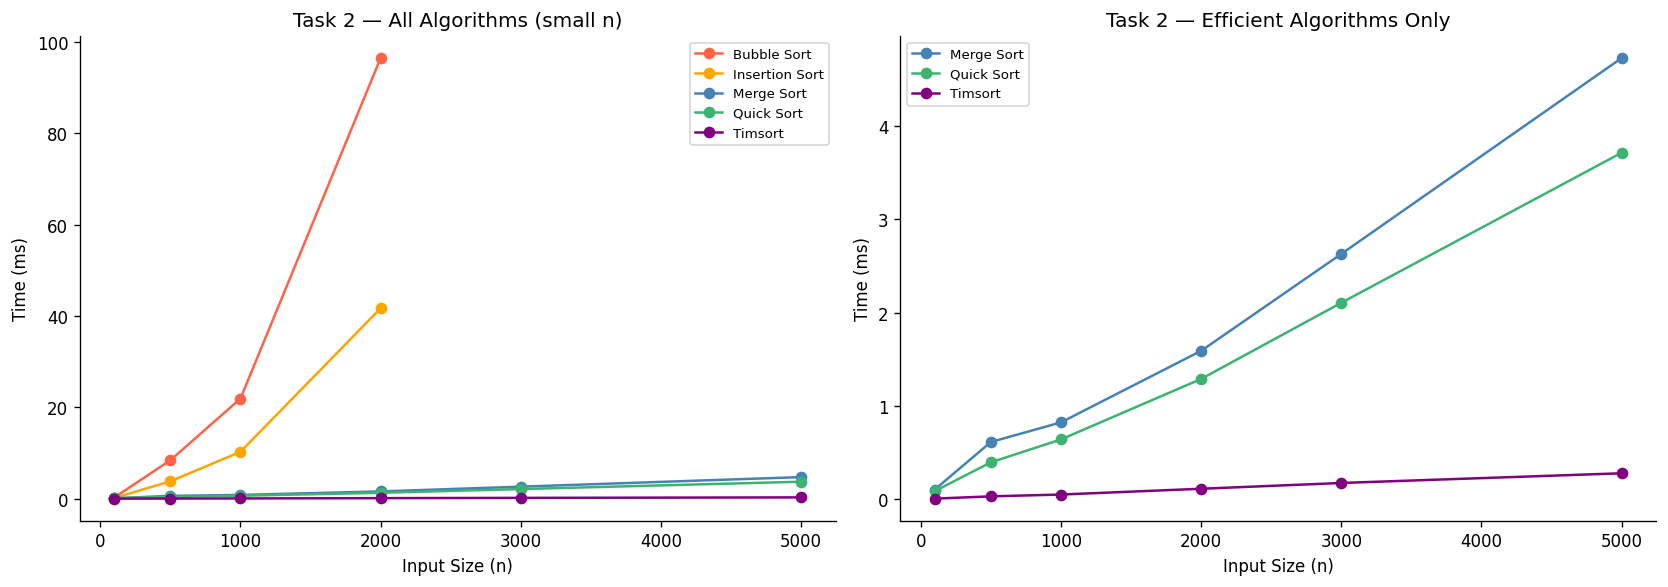

In [7]:
# ── 2.2  Benchmarking ────────────────────────────────────────────────────────

sizes_sort   = [100, 500, 1000, 2000, 3000, 5000]
slow_limit   = 2000   # skip O(n²) for large n to save time
results_sort = {name: [] for name in algorithms}

for n in sizes_sort:
    data = [random.randint(0, n * 10) for _ in range(n)]
    for name, fn in algorithms.items():
        if name in ('Bubble Sort', 'Insertion Sort') and n > slow_limit:
            results_sort[name].append(None)  # too slow
            continue
        t0 = time.perf_counter()
        fn(data)
        results_sort[name].append((time.perf_counter() - t0) * 1000)

# ── Plot ─────────────────────────────────────────────────────────────────────
colors = ['tomato', 'orange', 'steelblue', 'mediumseagreen', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title, shown in [
    (axes[0], 'All Algorithms (small n)', list(algorithms.keys())),
    (axes[1], 'Efficient Algorithms Only', ['Merge Sort', 'Quick Sort', 'Timsort']),
]:
    for name, color in zip(algorithms.keys(), colors):
        if name not in shown:
            continue
        xs = [s for s, v in zip(sizes_sort, results_sort[name]) if v is not None]
        ys = [v for v in results_sort[name] if v is not None]
        ax.plot(xs, ys, 'o-', color=color, label=name)
    ax.set_xlabel('Input Size (n)')
    ax.set_ylabel('Time (ms)')
    ax.set_title(f'Task 2 — {title}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Task 3 — Greedy Algorithms

**Strategy:** At each step pick the locally optimal choice, hoping it leads to a global optimum.  
**Algorithms implemented:**
- **Activity Selection** — maximise non-overlapping activities
- **Fractional Knapsack** — maximise value with weight constraint (fractions allowed)
- **Huffman Coding** — minimum-length prefix code for data compression
- **Coin Change (greedy)** — minimum coins for a denomination set

In [8]:
# ── 3.1  Activity Selection ──────────────────────────────────────────────────

def activity_selection(activities):
    """
    Greedy: sort by finish time, greedily pick non-overlapping activities.
    Input : list of (start, finish, name)
    Returns: list of selected activity names.
    Complexity: O(n log n)  — dominated by sort
    """
    sorted_acts = sorted(activities, key=lambda x: x[1])
    selected = [sorted_acts[0]]
    last_finish = sorted_acts[0][1]
    for start, finish, name in sorted_acts[1:]:
        if start >= last_finish:
            selected.append((start, finish, name))
            last_finish = finish
    return selected

activities = [
    (1, 4, 'A1'), (3, 5, 'A2'), (0, 6, 'A3'),
    (5, 7, 'A4'), (3, 9, 'A5'), (5, 9, 'A6'),
    (6, 10, 'A7'), (8, 11, 'A8'), (8, 12, 'A9'),
    (2, 14, 'A10'), (12, 16, 'A11'),
]

chosen = activity_selection(activities)
print('Activity Selection Result:')
print(f'  Selected {len(chosen)} activities:', [a[2] for a in chosen])
print(f'  Schedule: {[(a[0], a[1], a[2]) for a in chosen]}')

Activity Selection Result:
  Selected 4 activities: ['A1', 'A4', 'A8', 'A11']
  Schedule: [(1, 4, 'A1'), (5, 7, 'A4'), (8, 11, 'A8'), (12, 16, 'A11')]


In [9]:
# ── 3.2  Fractional Knapsack ─────────────────────────────────────────────────

def fractional_knapsack(capacity, items):
    """
    Greedy: sort by value/weight ratio descending, take as much as possible.
    Input : capacity (float), items = list of (weight, value, name)
    Returns: (total_value, breakdown)
    Complexity: O(n log n)
    """
    sorted_items = sorted(items, key=lambda x: x[1] / x[0], reverse=True)
    total_value  = 0.0
    breakdown    = []
    remaining    = capacity

    for weight, value, name in sorted_items:
        if remaining <= 0:
            break
        fraction  = min(1.0, remaining / weight)
        taken_val = fraction * value
        total_value  += taken_val
        remaining    -= fraction * weight
        breakdown.append((name, round(fraction, 3), round(taken_val, 2)))

    return round(total_value, 2), breakdown

items = [
    (10, 60, 'Item-A'),
    (20, 100, 'Item-B'),
    (30, 120, 'Item-C'),
]
capacity = 50
val, breakdown = fractional_knapsack(capacity, items)
print(f'Fractional Knapsack (capacity={capacity}):')
for name, frac, v in breakdown:
    print(f'  {name}: fraction={frac:.0%}, value gained={v}')
print(f'  Total value = {val}')

Fractional Knapsack (capacity=50):
  Item-A: fraction=100%, value gained=60.0
  Item-B: fraction=100%, value gained=100.0
  Item-C: fraction=67%, value gained=80.0
  Total value = 240.0


In [10]:
# ── 3.3  Huffman Coding ──────────────────────────────────────────────────────

import heapq
from collections import defaultdict

class HuffNode:
    def __init__(self, char, freq):
        self.char, self.freq = char, freq
        self.left = self.right = None
    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman(text):
    """
    Build Huffman tree from character frequencies.
    Complexity: O(n log n)
    """
    freq = defaultdict(int)
    for ch in text:
        freq[ch] += 1
    heap = [HuffNode(ch, f) for ch, f in freq.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        l = heapq.heappop(heap)
        r = heapq.heappop(heap)
        parent = HuffNode(None, l.freq + r.freq)
        parent.left, parent.right = l, r
        heapq.heappush(heap, parent)
    return heap[0]

def _generate_codes(node, prefix='', codes=None):
    if codes is None:
        codes = {}
    if node.char is not None:
        codes[node.char] = prefix or '0'
    else:
        _generate_codes(node.left,  prefix + '0', codes)
        _generate_codes(node.right, prefix + '1', codes)
    return codes

text = 'huffman coding greedy algorithm example'
root  = build_huffman(text)
codes = _generate_codes(root)

encoded = ''.join(codes[ch] for ch in text)
original_bits  = len(text) * 8
compressed_bits = len(encoded)
ratio = compressed_bits / original_bits

print('Huffman Codes:')
for ch, code in sorted(codes.items(), key=lambda x: len(x[1])):
    display = repr(ch) if ch == ' ' else ch
    print(f'  {display!r:6s} → {code}')
print(f'\nOriginal  : {original_bits} bits')
print(f'Compressed: {compressed_bits} bits')
print(f'Ratio     : {ratio:.2%}  ({100*(1-ratio):.1f}% savings)')

Huffman Codes:
  'e'    → 000
  'o'    → 0011
  'r'    → 0100
  'n'    → 0101
  'f'    → 0110
  'h'    → 0111
  'i'    → 1000
  'd'    → 1001
  'l'    → 1010
  'g'    → 1011
  'a'    → 1100
  'm'    → 1101
  "' '"  → 1110
  'x'    → 00100
  'u'    → 00101
  'y'    → 111100
  'p'    → 111101
  't'    → 111110
  'c'    → 111111

Original  : 312 bits
Compressed: 162 bits
Ratio     : 51.92%  (48.1% savings)


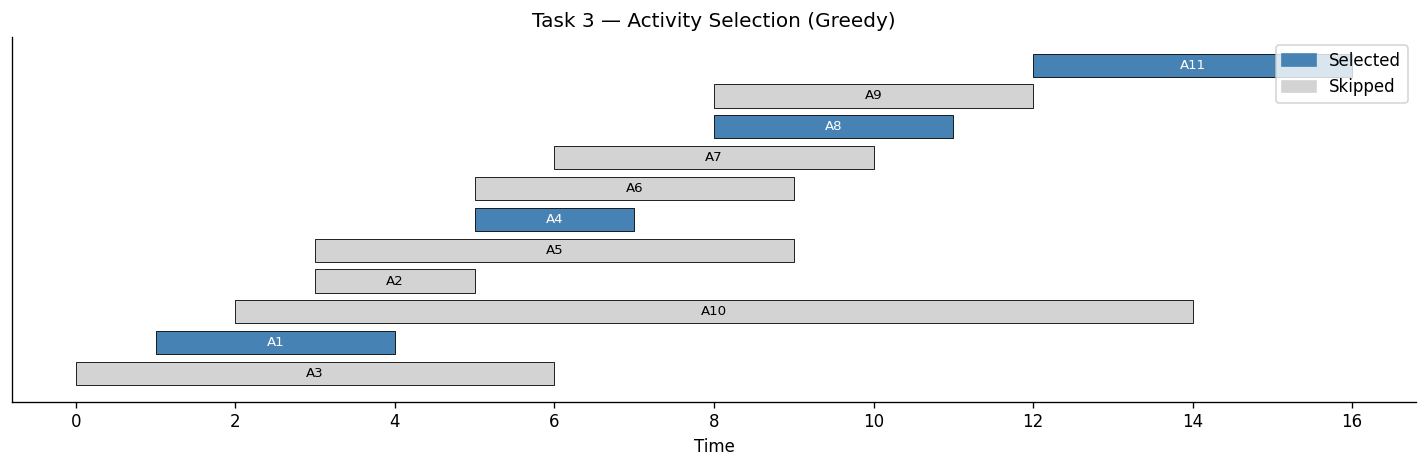

In [19]:
# ── 3.4 Visualisation — Activity Timeline ────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 4))
selected_names = {a[2] for a in chosen}

for i, (start, finish, name) in enumerate(sorted(activities, key=lambda x: x[0])):
    color = 'steelblue' if name in selected_names else 'lightgray'
    ax.broken_barh([(start, finish - start)], (i * 0.8, 0.6),
                   facecolors=color, edgecolors='black', linewidth=0.5)
    ax.text((start + finish) / 2, i * 0.8 + 0.3, name,
            ha='center', va='center', fontsize=8,
            color='white' if name in selected_names else 'black')

selected_patch = mpatches.Patch(color='steelblue', label='Selected')
skipped_patch  = mpatches.Patch(color='lightgray',  label='Skipped')
ax.legend(handles=[selected_patch, skipped_patch], loc='upper right')
ax.set_xlabel('Time')
ax.set_title('Task 3 — Activity Selection (Greedy)')
ax.set_yticks([])
plt.tight_layout()
plt.show()


## Task 4 — Dynamic Programming Fundamentals

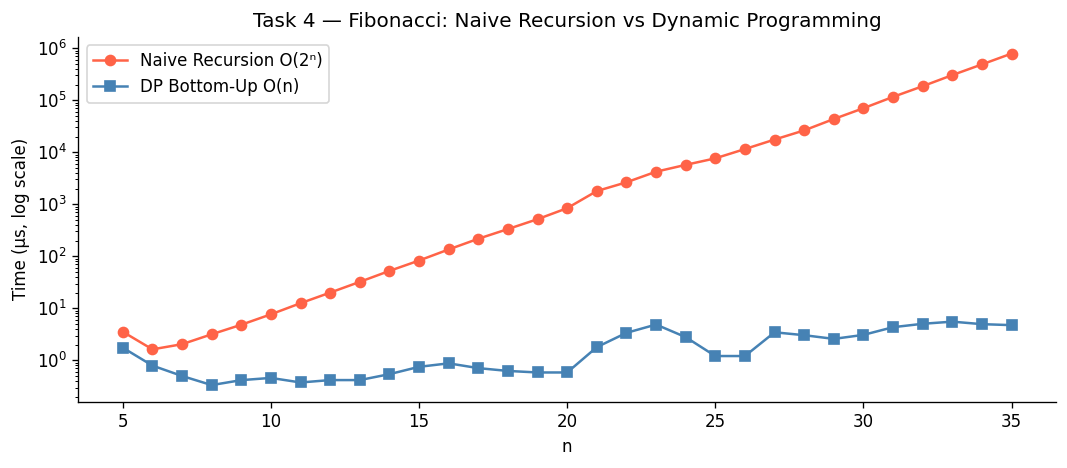

fib(35) = 9227465


In [13]:
# ── 4.1  Fibonacci — Naive vs DP ─────────────────────────────────────────────

import sys
sys.setrecursionlimit(10000)

def fib_naive(n, _cache={}):
    """Naive recursion — O(2^n) without memo."""
    if n <= 1:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)

def fib_dp(n):
    """Bottom-up DP — O(n) time, O(1) space."""
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

# Benchmark
test_ns = list(range(5, 36))
times_naive, times_dp = [], []

for n in test_ns:
    t0 = time.perf_counter(); fib_naive(n); times_naive.append((time.perf_counter()-t0)*1e6)
    t0 = time.perf_counter(); fib_dp(n);   times_dp.append((time.perf_counter()-t0)*1e6)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(test_ns, times_naive, 'o-', color='tomato', label='Naive Recursion O(2ⁿ)')
ax.semilogy(test_ns, times_dp,    's-', color='steelblue', label='DP Bottom-Up O(n)')
ax.set_xlabel('n'); ax.set_ylabel('Time (μs, log scale)')
ax.set_title('Task 4 — Fibonacci: Naive Recursion vs Dynamic Programming')
ax.legend()
plt.tight_layout()
plt.show()
print(f'fib(35) = {fib_dp(35)}')

In [14]:
# ── 4.2  0/1 Knapsack ────────────────────────────────────────────────────────

def knapsack_01(capacity, weights, values):
    """
    Standard 0/1 Knapsack via bottom-up DP table.
    Time: O(n * W),  Space: O(n * W)
    Returns (max_value, selected_item_indices, dp_table)
    """
    n   = len(weights)
    dp  = [[0] * (capacity + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i - 1] <= w:
                dp[i][w] = max(dp[i-1][w],
                               dp[i-1][w - weights[i-1]] + values[i-1])
            else:
                dp[i][w] = dp[i-1][w]

    # Backtrack to find selected items
    selected, w = [], capacity
    for i in range(n, 0, -1):
        if dp[i][w] != dp[i-1][w]:
            selected.append(i - 1)
            w -= weights[i - 1]

    return dp[n][capacity], selected[::-1], dp

weights  = [2, 3, 4, 5, 1]
values   = [3, 4, 5, 6, 1]
capacity = 8
names    = ['Item-0', 'Item-1', 'Item-2', 'Item-3', 'Item-4']

max_val, selected_items, dp_table = knapsack_01(capacity, weights, values)

print(f'0/1 Knapsack (capacity={capacity}):')
print(f'  Max value    = {max_val}')
print(f'  Items taken  = {[names[i] for i in selected_items]}')
total_w = sum(weights[i] for i in selected_items)
print(f'  Total weight = {total_w} / {capacity}')

# Show DP table
print('\nDP Table (rows=items, cols=capacity):')
header = '     ' + ' '.join(f'{w:3d}' for w in range(capacity + 1))
print(header)
print('     ' + '---' * (capacity + 1))
for i, row in enumerate(dp_table):
    label = f'I{i-1} |' if i > 0 else 'I0 |'
    print(f'{label:5s}' + ' '.join(f'{v:3d}' for v in row))

0/1 Knapsack (capacity=8):
  Max value    = 10
  Items taken  = ['Item-1', 'Item-3']
  Total weight = 8 / 8

DP Table (rows=items, cols=capacity):
       0   1   2   3   4   5   6   7   8
     ---------------------------
I0 |   0   0   0   0   0   0   0   0   0
I0 |   0   0   3   3   3   3   3   3   3
I1 |   0   0   3   4   4   7   7   7   7
I2 |   0   0   3   4   5   7   8   9   9
I3 |   0   0   3   4   5   7   8   9  10
I4 |   0   1   3   4   5   7   8   9  10


In [ ]:
# ── 4.3  Bellman-Ford Shortest Path ──────────────────────────────────────────

def bellman_ford(vertices, edges, source):
    """
    Single-source shortest paths with negative edge support.
    Time: O(V * E),  Space: O(V)
    Returns dist dict or raises if negative cycle detected.
    """
    dist = {v: float('inf') for v in vertices}
    dist[source] = 0

    for _ in range(len(vertices) - 1):
        for u, v, w in edges:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w

    # Negative-cycle detection
    for u, v, w in edges:
        if dist[u] + w < dist[v]:
            raise ValueError('Graph contains a negative-weight cycle')

    return dist

vertices = ['A', 'B', 'C', 'D', 'E']
edges    = [
    ('A', 'B', -1), ('A', 'C',  4),
    ('B', 'C',  3), ('B', 'D',  2), ('B', 'E',  2),
    ('D', 'B',  1), ('D', 'C',  5),
    ('E', 'D', -3),
]

distances = bellman_ford(vertices, edges, 'A')
print('Bellman-Ford Shortest Distances from A:')
for v, d in distances.items():
    print(f'  A → {v} = {d}')

Bellman-Ford Shortest Distances from A:
  A → A = 0
  A → B = -1
  A → C = 2
  A → D = -2
  A → E = 1


## Task 5 — Travelling Salesman Problem (TSP)

**Problem:** Find the shortest Hamiltonian cycle visiting all cities exactly once.  
**Complexity:** NP-Hard — no known polynomial-time exact algorithm. 

In [17]:
# ── 5.1  Distance Helper ─────────────────────────────────────────────────────

def euclidean(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def build_dist_matrix(cities):
    n = len(cities)
    return [[euclidean(cities[i], cities[j]) for j in range(n)] for i in range(n)]

def tour_length(tour, dist):
    return sum(dist[tour[i]][tour[i+1]] for i in range(len(tour)-1)) + dist[tour[-1]][tour[0]]


# ── 5.2  Brute Force TSP ─────────────────────────────────────────────────────

def tsp_brute_force(dist):
    """
    Exact solution via all permutations.
    Time: O((n-1)!)  — only feasible up to ~10 cities.
    """
    n = len(dist)
    nodes = list(range(1, n))
    best_tour, best_cost = None, float('inf')
    for perm in itertools.permutations(nodes):
        tour = [0] + list(perm)
        cost = tour_length(tour, dist)
        if cost < best_cost:
            best_cost, best_tour = cost, tour
    return best_tour, best_cost


# ── 5.3  Held-Karp DP TSP ────────────────────────────────────────────────────

def tsp_held_karp(dist):
    """
    Exact solution via bitmask DP.
    Time: O(n² 2ⁿ),  Space: O(n 2ⁿ)
    """
    n    = len(dist)
    INF  = float('inf')
    full = (1 << n) - 1
    memo = [[INF] * n for _ in range(1 << n)]
    prev = [[-1]  * n for _ in range(1 << n)]

    memo[1][0] = 0  # start at city 0, visited = {0}

    for mask in range(1, 1 << n):
        for u in range(n):
            if not (mask >> u & 1) or memo[mask][u] == INF:
                continue
            for v in range(n):
                if mask >> v & 1:
                    continue
                new_mask = mask | (1 << v)
                new_cost = memo[mask][u] + dist[u][v]
                if new_cost < memo[new_mask][v]:
                    memo[new_mask][v] = new_cost
                    prev[new_mask][v] = u

    # Find best ending city
    best_cost, last = INF, -1
    for u in range(1, n):
        cost = memo[full][u] + dist[u][0]
        if cost < best_cost:
            best_cost, last = cost, u

    # Reconstruct tour
    tour, mask, cur = [0], full, last
    while cur != -1:
        tour.append(cur)
        nxt = prev[mask][cur]
        mask ^= (1 << cur)
        cur = nxt
    tour.reverse()

    return tour, best_cost


# ── 5.4  Greedy Nearest Neighbor ─────────────────────────────────────────────

def tsp_nearest_neighbor(dist, start=0):
    """
    Heuristic: always move to the closest unvisited city.
    Time: O(n²)  — fast but not necessarily optimal.
    """
    n = len(dist)
    visited = [False] * n
    tour    = [start]
    visited[start] = True
    for _ in range(n - 1):
        current = tour[-1]
        nearest = min((j for j in range(n) if not visited[j]),
                      key=lambda j: dist[current][j])
        tour.append(nearest)
        visited[nearest] = True
    return tour, tour_length(tour, dist)


# ── 5.5  Demo on Small Instance ──────────────────────────────────────────────

random.seed(42)
small_cities = [(random.randint(0, 100), random.randint(0, 100)) for _ in range(8)]
dist_small   = build_dist_matrix(small_cities)

t0 = time.perf_counter()
bf_tour, bf_cost = tsp_brute_force(dist_small)
bf_time = time.perf_counter() - t0

t0 = time.perf_counter()
hk_tour, hk_cost = tsp_held_karp(dist_small)
hk_time = time.perf_counter() - t0

t0 = time.perf_counter()
nn_tour, nn_cost = tsp_nearest_neighbor(dist_small)
nn_time = time.perf_counter() - t0

print('TSP Results (8 cities):')
print(f'  Brute Force      : cost={bf_cost:.2f}  time={bf_time*1000:.2f}ms  tour={bf_tour}')
print(f'  Held-Karp DP     : cost={hk_cost:.2f}  time={hk_time*1000:.2f}ms  tour={hk_tour}')
print(f'  Nearest Neighbor : cost={nn_cost:.2f}  time={nn_time*1000:.2f}ms  tour={nn_tour}')
print(f'  NN excess over optimal: {(nn_cost/bf_cost - 1)*100:.1f}%')

TSP Results (8 cities):
  Brute Force      : cost=322.83  time=4.70ms  tour=[0, 4, 7, 5, 1, 2, 3, 6]
  Held-Karp DP     : cost=322.83  time=0.48ms  tour=[0, 4, 7, 5, 1, 2, 3, 6, 0]
  Nearest Neighbor : cost=413.52  time=0.04ms  tour=[0, 6, 4, 7, 5, 2, 3, 1]
  NN excess over optimal: 28.1%


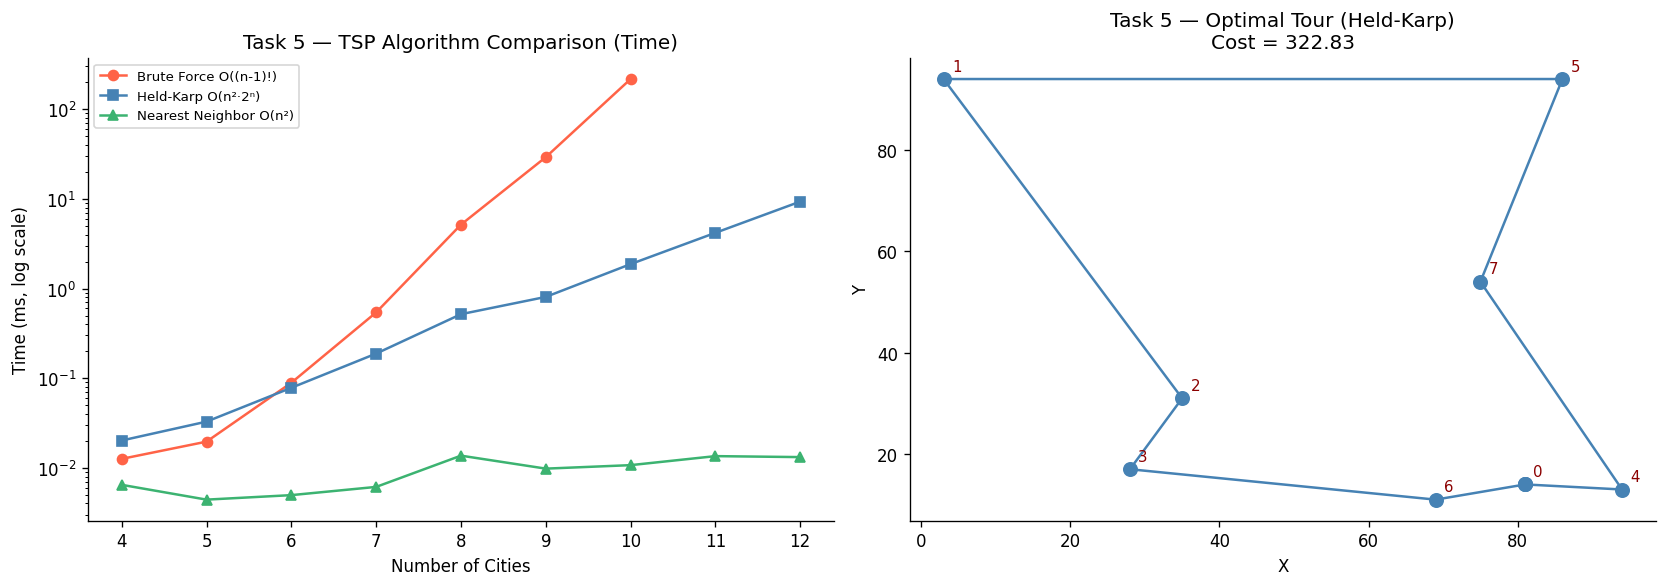

Plot saved → images/task5_tsp.png


In [18]:
# ── 5.6  Exponential Growth Demonstration ────────────────────────────────────

city_counts = list(range(4, 13))
bf_times, hk_times, nn_times = [], [], []

for n in city_counts:
    cities = [(random.randint(0, 100), random.randint(0, 100)) for _ in range(n)]
    dist   = build_dist_matrix(cities)

    if n <= 10:
        t0 = time.perf_counter(); tsp_brute_force(dist)
        bf_times.append((time.perf_counter() - t0) * 1000)
    else:
        bf_times.append(None)

    t0 = time.perf_counter(); tsp_held_karp(dist)
    hk_times.append((time.perf_counter() - t0) * 1000)

    t0 = time.perf_counter(); tsp_nearest_neighbor(dist)
    nn_times.append((time.perf_counter() - t0) * 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: time comparison
ax = axes[0]
xs_bf = [n for n, t in zip(city_counts, bf_times) if t is not None]
ys_bf = [t for t in bf_times if t is not None]
ax.semilogy(xs_bf,     ys_bf,   'o-', color='tomato',       label='Brute Force O((n-1)!)')
ax.semilogy(city_counts, hk_times, 's-', color='steelblue',   label='Held-Karp O(n²·2ⁿ)')
ax.semilogy(city_counts, nn_times, '^-', color='mediumseagreen', label='Nearest Neighbor O(n²)')
ax.set_xlabel('Number of Cities'); ax.set_ylabel('Time (ms, log scale)')
ax.set_title('Task 5 — TSP Algorithm Comparison (Time)')
ax.legend(fontsize=8)

# Right: route visualisation for 8-city optimal tour
ax2 = axes[1]
opt_route = hk_tour + [hk_tour[0]]
xs = [small_cities[i][0] for i in opt_route]
ys = [small_cities[i][1] for i in opt_route]
ax2.plot(xs, ys, 'o-', color='steelblue', markersize=8)
for i, (cx, cy) in enumerate(small_cities):
    ax2.annotate(str(i), (cx, cy), textcoords='offset points',
                 xytext=(5, 5), fontsize=9, color='darkred')
ax2.set_title(f'Task 5 — Optimal Tour (Held-Karp)\nCost = {hk_cost:.2f}')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')

plt.tight_layout()

plt.show()
print('Plot saved → images/task5_tsp.png')